# NeuroQA Phase 1 — an endpoint-aware contamination score, tested against a real depression marker

**One-sentence version:** don't build a classifier, don't build a cleaner — detect artifacts with
MNE, score each one by how much its frequency band overlaps the band we're about to measure, and
use that score to test whether a known depression marker (frontal alpha asymmetry, FAA) is partly
contamination.

This notebook runs the whole Phase 1 pipeline end to end against **three real public datasets**,
calling the exact same `manifest.py` / `pipeline.py` / `study_a.py` / `study_b.py` functions
`run_local.py` (offline CLI) and `webapp.py` (the deployed app's `/api/*` routes) call — one
implementation of "how a recording gets scored," not a copy embedded here. Seeded throughout
(`pipeline.SEED = 0` drives ICA/AutoReject/CV); re-running this notebook against the same data
reproduces the same numbers.

**[ds003478](https://openneuro.org/datasets/ds003478)** ("EEG: Depression rest", Cavanagh lab /
Univ. of Arizona, CC0): 119 resting-EEG recordings matching the dataset's own published high-BDI
(>13) / control (<7) groups, real per-subject BDI severity from `participants.tsv`.

**[ds007615](https://openneuro.org/datasets/ds007615)** ("LDAEP and resting-state EEG in healthy
women", Univ. of Oslo, CC0): 49 recordings, same BDI(>13)/BDI(<7) thresholds applied to a real
per-subject BDI-II score (`phenotype/bdi.tsv`) — an independent cohort from a different lab, not
overlapping with ds003478's subjects.

**Mumtaz/HUSM** (figshare 4244171, CC BY 4.0): 58 eyes-closed recordings, H/MDD labels only,
**no severity score in this public deposit** — Test B.1 is skipped for it by design (see
`study_b.py`'s `regression_1_skipped_reason`), Test A and Test B.2/confound-check still run as an
independent check on the same questions.

Both ds003478 and ds007615 carry real per-subject severity, so Test B.1 runs on two independent
cohorts, not one.

**Read this before the numbers below:** `WEIGHT[artifact.type]` and the artifact/endpoint overlap
logic are domain calls — supplied as placeholders here (`bands.py`, every weight = 1.0), pending
the real physics-derived values from Peter. Nothing in this notebook or the rest of the repo tunes
them against an accuracy number. See Part 8 (Caveats) for what that means for interpreting the
results below.

In [1]:
import sys
from pathlib import Path

NEUROQA_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(NEUROQA_DIR))
REPO_ROOT = NEUROQA_DIR.parent

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATASETS = {
    "ds003478": {"label": "ds003478 (real BDI severity)",
                 "data_dir": REPO_ROOT / "data" / "ds003478",
                 "out_dir": REPO_ROOT / "outputs" / "ds003478"},
    "ds007615": {"label": "ds007615 (real BDI-II severity)",
                 "data_dir": REPO_ROOT / "data" / "ds007615",
                 "out_dir": REPO_ROOT / "outputs" / "ds007615"},
    "mumtaz": {"label": "Mumtaz/HUSM (no severity)",
               "data_dir": REPO_ROOT / "data" / "mumtaz",
               "out_dir": REPO_ROOT / "outputs" / "mumtaz"},
}
for d in DATASETS.values():
    print(d["label"], "->", d["out_dir"])

ds003478 (real BDI severity) -> C:\Users\RyanC\Documents\eegtest\outputs\ds003478
ds007615 (real BDI-II severity) -> C:\Users\RyanC\Documents\eegtest\outputs\ds007615
Mumtaz/HUSM (no severity) -> C:\Users\RyanC\Documents\eegtest\outputs\mumtaz


## 1. Data loader

Both datasets go through `manifest.validate_batch` — the same per-file validation (labeled,
F3/F4 present, raw not pre-cleaned, long/fast enough to epoch) and batch-level group check
(`MIN_PER_GROUP` per label) that a real upload through `/study` goes through. `validation.json`
below is `run_local.py`'s persisted output of exactly that call.

In [2]:
def load_validation(name):
    return json.loads((DATASETS[name]["out_dir"] / "validation.json").read_text())

for name in DATASETS:
    v = load_validation(name)
    n_acc, n_rej = len(v["accepted"]), len(v["rejected"])
    groups = pd.Series([a["diagnosis"] for a in v["accepted"]]).value_counts()
    n_sev = sum(1 for a in v["accepted"] if a.get("severity") is not None)
    print(f"--- {DATASETS[name]['label']} ---")
    print(f"  accepted: {n_acc}   rejected: {n_rej}   group_ok: {v['group_ok']}")
    print(f"  groups: {groups.to_dict()}")
    print(f"  with clinical severity: {n_sev}/{n_acc}")
    if v["rejected"]:
        print(f"  rejection reasons (first 3): {[r['reasons'] for r in v['rejected'][:3]]}")
    print()

--- ds003478 (real BDI severity) ---
  accepted: 119   rejected: 121   group_ok: True
  groups: {'healthy': 74, 'depressed': 45}
  with clinical severity: 119/119
  rejection reasons (first 3): [['no manifest row for this filename', "unsupported file type '.csv' -- expected one of ['.bdf', '.cnt', '.edf', '.fif', '.set', '.vhdr']"], ['no manifest row for this filename', "unsupported file type '.tsv' -- expected one of ['.bdf', '.cnt', '.edf', '.fif', '.set', '.vhdr']"], ['no manifest row for this filename', "unsupported file type '.fdt' -- expected one of ['.bdf', '.cnt', '.edf', '.fif', '.set', '.vhdr']"]]

--- ds007615 (real BDI-II severity) ---
  accepted: 49   rejected: 100   group_ok: True
  groups: {'healthy': 37, 'depressed': 12}
  with clinical severity: 49/49
  rejection reasons (first 3): [['no manifest row for this filename', "unsupported file type '.tsv' -- expected one of ['.bdf', '.cnt', '.edf', '.fif', '.set', '.vhdr']"], ['no manifest row for this filename', "unsupporte

## 2. The endpoint-aware quality index

The core idea: the same detected artifact gets a different penalty depending on which frequency
band we're about to measure (`ENDPOINT_BAND`). A blink is a huge penalty against delta/theta and
near-zero against alpha, because a blink's energy doesn't live in alpha.

```
for artifact in detected_artifacts(recording):
    overlap = spectral_overlap(artifact.band, ENDPOINT_BAND)
    penalty += artifact.severity * WEIGHT[artifact.type] * overlap
quality = f(penalty)
```

**Caveat worth flagging to Peter, not silently fixed here:** `ARTIFACT_BANDS["emg"] = (20, 45)` Hz
has **zero** `spectral_overlap` with alpha (8-13 Hz) under the current placeholder bands — detected
muscle artifact currently contributes *nothing* to the alpha-endpoint quality score below. That's
in tension with the brief's own stated hypothesis ("muscle noise sitting at the same frequency as
alpha"). Artifact-band assignment is a domain call, not this notebook's to widen — but it means
the quality-vs-alpha numbers in Part 5 below likely *underestimate* muscle contamination if real
EMG energy does extend into alpha. Confirm with Peter before treating Test B's alpha-quality
results as a clean test of the EMG-alpha overlap claim.

In [3]:
from bands import ARTIFACT_BANDS, EEG_BANDS, WEIGHT, spectral_overlap

alpha = EEG_BANDS["alpha"]
print(f"WEIGHT (placeholder, all equal until Peter's physics-derived values land): {WEIGHT}")
print()
for name, band in ARTIFACT_BANDS.items():
    print(f"  spectral_overlap({name:11s} {band}, alpha {alpha}) = {spectral_overlap(band, alpha):.2f}")

WEIGHT (placeholder, all equal until Peter's physics-derived values land): {'eog': 1.0, 'emg': 1.0, 'pop': 1.0, 'line_noise': 1.0, 'motion': 1.0, 'cardiac': 1.0}

  spectral_overlap(eog         (0.5, 4.0), alpha (8.0, 13.0)) = 0.00
  spectral_overlap(emg         (20.0, 45.0), alpha (8.0, 13.0)) = 0.00
  spectral_overlap(pop         (0.5, 45.0), alpha (8.0, 13.0)) = 0.11
  spectral_overlap(line_noise  (49.0, 51.0), alpha (8.0, 13.0)) = 0.00
  spectral_overlap(motion      (0.5, 45.0), alpha (8.0, 13.0)) = 0.11
  spectral_overlap(cardiac     (0.8, 2.0), alpha (8.0, 13.0)) = 0.00


## 3. Quality + FAA, per recording

`quality_alpha_pct` is the endpoint-aware score above with `ENDPOINT_BAND = alpha`; `faa` is
`ln(alpha power at F4) - ln(alpha power at F3)` under the "ours" pipeline (every epoch kept,
weighted by its own alpha-band quality — see `faa.py`/`quality_index.py`), the same computation
`score_and_faa()` returns for every accepted upload.

In [4]:
summaries = {}
for name in DATASETS:
    df = pd.read_csv(DATASETS[name]["out_dir"] / "quality_faa_summary.csv")
    summaries[name] = df
    print(f"--- {DATASETS[name]['label']}: {len(df)} recordings ---")
    display(df.groupby("group")[["quality_alpha_pct", "faa"]].agg(["mean", "std", "count"]))
    print()

--- ds003478 (real BDI severity): 119 recordings ---


quality_alpha_pct                       faa                
                       mean       std count      mean       std count
group                                                                
depressed         98.132444  0.750079    45  0.057491  0.213295    45
healthy           98.003919  1.526679    74  0.160091  0.673463    74


--- ds007615 (real BDI-II severity): 49 recordings ---


quality_alpha_pct                       faa                
                       mean       std count      mean       std count
group                                                                
depressed         99.521667  0.159763    12 -0.003117  0.073315    12
healthy           99.461081  0.710304    37  0.050581  0.063310    37


--- Mumtaz/HUSM (no severity): 58 recordings ---


quality_alpha_pct                       faa                
                       mean       std count      mean       std count
group                                                                
depressed         97.036667  1.066895    30  0.061270  0.097668    30
healthy           97.096429  0.765207    28  0.151725  0.489359    28

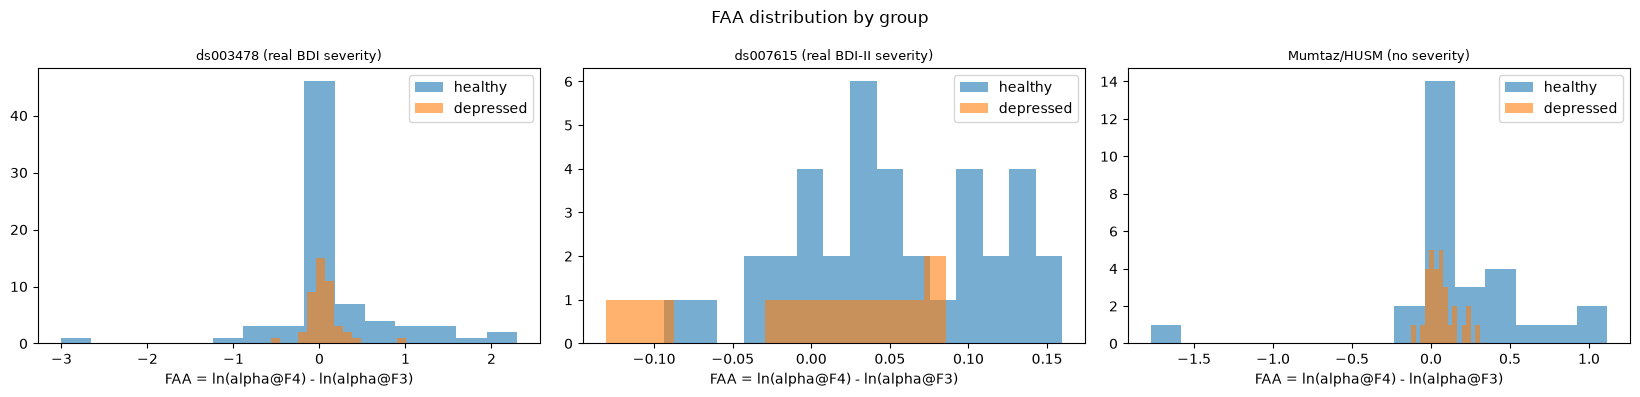

In [5]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.5 * len(DATASETS), 4))
for ax, name in zip(axes, DATASETS):
    df = summaries[name]
    for group, color in [("healthy", "tab:blue"), ("depressed", "tab:orange")]:
        vals = df.loc[df.group == group, "faa"]
        ax.hist(vals, bins=15, alpha=0.6, label=group, color=color)
    ax.set_title(DATASETS[name]["label"], fontsize=9)
    ax.set_xlabel("FAA = ln(alpha@F4) - ln(alpha@F3)")
    ax.legend()
fig.suptitle("FAA distribution by group")
fig.tight_layout()
FIG_DIR = REPO_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "faa_by_group.png", dpi=120)
plt.show()

## 4. Test A — does the cleaning choice decide the FAA-group answer?

FAA for the same recording under 5 preprocessing pipelines (raw / ICA / generic reject /
AutoReject / "ours" — the endpoint-aware quality-weighted average) × 2 reference schemes
(original-as-shipped / average), for a bounded subsample per dataset (`STUDY_A_N_PER_GROUP = 6`
per group — ICA+AutoReject are the slow steps; this question is about spread, not statistical
power, see `pipeline.py`). **Red flag:** a big swing across pipelines means the FAA-group
conclusion is substantially a preprocessing artifact, not a robust finding.

In [6]:
study_a_wide = {}
all_results = {}
for name in DATASETS:
    results = json.loads((DATASETS[name]["out_dir"] / "results.json").read_text())
    all_results[name] = results
    wide = pd.DataFrame(results["study_a"]["wide"])
    study_a_wide[name] = wide
    print(f"--- {DATASETS[name]['label']}: {len(wide)} recordings x "
          f"{len(results['study_a']['combo_cols'])} pipeline x reference combos ---")
    print(f"  FAA range per subject: median {wide.faa_range.median():.3f}, "
          f"max {wide.faa_range.max():.3f}, mean {wide.faa_range.mean():.3f}")
display(study_a_wide["ds003478"][["file", "group", "faa_range", "faa_std"]])

--- ds003478 (real BDI severity): 12 recordings x 10 pipeline x reference combos ---
  FAA range per subject: median 0.253, max 1.917, mean 0.536
--- ds007615 (real BDI-II severity): 12 recordings x 10 pipeline x reference combos ---
  FAA range per subject: median 0.099, max 0.673, mean 0.158
--- Mumtaz/HUSM (no severity): 12 recordings x 10 pipeline x reference combos ---
  FAA range per subject: median 0.168, max 0.964, mean 0.281


,file,group,faa_range,faa_std
0,sub-052_task-Rest_run-01_eeg.set,depressed,0.6203,0.259661
1,sub-053_task-Rest_run-01_eeg.set,depressed,0.1037,0.029946
2,sub-055_task-Rest_run-01_eeg.set,depressed,0.3435,0.111220
3,sub-058_task-Rest_run-01_eeg.set,depressed,0.5245,0.125738
4,sub-059_task-Rest_run-01_eeg.set,depressed,0.0474,0.016967
5,sub-060_task-Rest_run-01_eeg.set,depressed,0.1555,0.048270
6,sub-001_task-Rest_run-01_eeg.set,healthy,0.6417,0.298315
7,sub-002_task-Rest_run-01_eeg.set,healthy,1.6529,0.633966
8,sub-004_task-Rest_run-01_eeg.set,healthy,1.9175,0.802193
9,sub-005_task-Rest_run-01_eeg.set,healthy,0.1629,0.068637


C:\Users\RyanC\AppData\Local\Temp\ipykernel_27212\4007174317.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_by_name, tick_labels=[DATASETS[n]["label"] for n in DATASETS], vert=True)


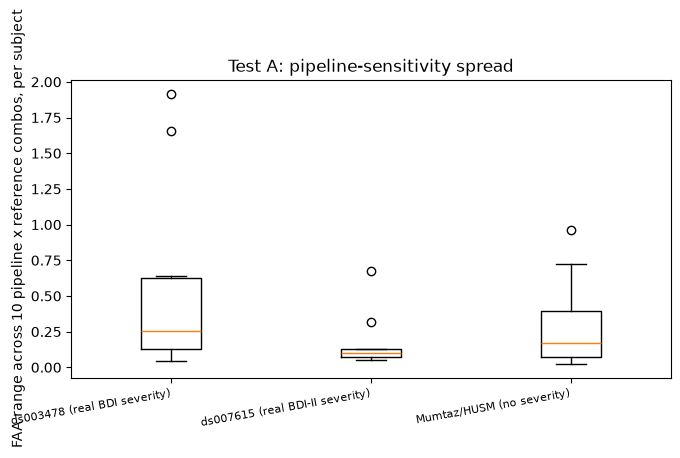

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
data_by_name = [study_a_wide[n].faa_range.dropna().values for n in DATASETS]
ax.boxplot(data_by_name, tick_labels=[DATASETS[n]["label"] for n in DATASETS], vert=True)
ax.set_ylabel("FAA range across 10 pipeline x reference combos, per subject")
ax.set_title("Test A: pipeline-sensitivity spread")
plt.xticks(rotation=10, ha="right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "study_a_faa_spread.png", dpi=120)
plt.show()

## 4b. Five independent FAA-only classifiers, one per pipeline

A request from Peter (domain): not just "how much does FAA move across pipelines" (Test A above),
but 4-5 *independent* classifiers — one per preprocessing pipeline, each one only using that
pipeline's own FAA number to guess depressed/healthy, none sharing data or influencing each
other — with a result reported for each (`faa_classifiers.classify_by_pipeline`, wired into
`pipeline.aggregate()` so it's part of every run's `results.json` going forward, not a one-off
script). Runs on the same bounded Study A subsample (12 recordings) as Test A, so treat n=12
results as indicative, not conclusive — same statistical-power caveat as Test A.

In [8]:
clf_rows = []
for name in DATASETS:
    clf = all_results[name]["faa_classifiers_by_pipeline"]
    print(f"--- {DATASETS[name]['label']} ---")
    for pipeline_name, r in clf.items():
        if "error" in r:
            print(f"  {pipeline_name:12s} SKIPPED -- {r['error']}")
            continue
        print(f"  {pipeline_name:12s} accuracy={r['accuracy']:.2f}  AUC={r['auc']:.2f}  "
              f"(baseline {r['baseline']:.2f}, n={r['n']})")
        clf_rows.append({"dataset": name, "pipeline": pipeline_name, **r})
    print()
clf_df = pd.DataFrame(clf_rows)
display(clf_df)

--- ds003478 (real BDI severity) ---
  raw          accuracy=0.33  AUC=0.22  (baseline 0.50, n=12)
  ica          accuracy=0.33  AUC=0.22  (baseline 0.50, n=12)
  generic      accuracy=0.58  AUC=0.42  (baseline 0.50, n=12)
  autoreject   accuracy=0.42  AUC=0.25  (baseline 0.50, n=12)
  ours         accuracy=0.33  AUC=0.22  (baseline 0.50, n=12)

--- ds007615 (real BDI-II severity) ---
  raw          accuracy=0.50  AUC=0.36  (baseline 0.50, n=12)
  ica          accuracy=0.50  AUC=0.33  (baseline 0.50, n=12)
  generic      accuracy=0.33  AUC=0.31  (baseline 0.50, n=12)
  autoreject   accuracy=0.58  AUC=0.39  (baseline 0.50, n=12)
  ours         accuracy=0.50  AUC=0.36  (baseline 0.50, n=12)

--- Mumtaz/HUSM (no severity) ---
  raw          accuracy=0.33  AUC=0.31  (baseline 0.50, n=12)
  ica          accuracy=0.33  AUC=0.31  (baseline 0.50, n=12)
  generic      accuracy=0.33  AUC=0.39  (baseline 0.50, n=12)
  autoreject   accuracy=0.42  AUC=0.39  (baseline 0.50, n=12)
  ours         accu

,dataset,pipeline,accuracy,auc,baseline,n,n_splits
0,ds003478,raw,0.333333,0.222222,0.5,12,5
1,ds003478,ica,0.333333,0.222222,0.5,12,5
2,ds003478,generic,0.583333,0.416667,0.5,12,5
3,ds003478,autoreject,0.416667,0.250000,0.5,12,5
4,ds003478,ours,0.333333,0.222222,0.5,12,5
5,ds007615,raw,0.500000,0.361111,0.5,12,5
6,ds007615,ica,0.500000,0.333333,0.5,12,5
7,ds007615,generic,0.333333,0.305556,0.5,12,5
8,ds007615,autoreject,0.583333,0.388889,0.5,12,5
9,ds007615,ours,0.500000,0.361111,0.5,12,5


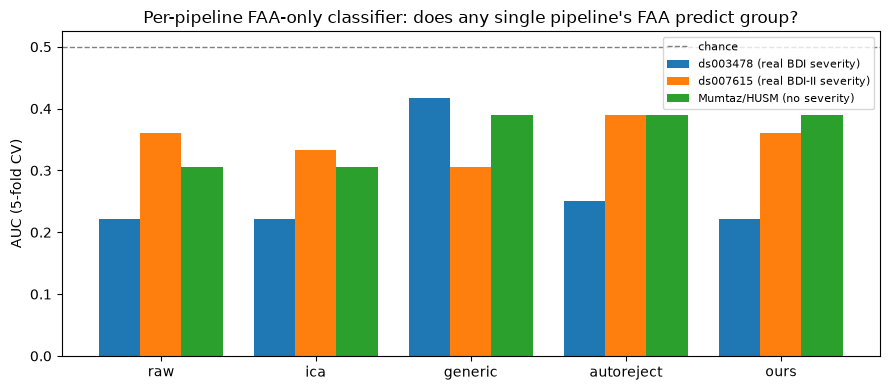

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
n_ds = len(DATASETS)
width = 0.8 / n_ds
x = np.arange(len(PIPELINES := ["raw", "ica", "generic", "autoreject", "ours"]))
for i, name in enumerate(DATASETS):
    sub = clf_df[clf_df.dataset == name].set_index("pipeline").reindex(PIPELINES)
    ax.bar(x + i * width, sub["auc"], width, label=DATASETS[name]["label"])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance")
ax.set_xticks(x + width * (n_ds - 1) / 2)
ax.set_xticklabels(PIPELINES)
ax.set_ylabel("AUC (5-fold CV)")
ax.set_title("Per-pipeline FAA-only classifier: does any single pipeline's FAA predict group?")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "faa_classifiers_by_pipeline.png", dpi=120)
plt.show()

## 5. Test B — is contamination itself tied to diagnosis?

Three analyses (`study_b.run_study_b`):

1. **B.1** `quality ~ group + severity` — clinical severity (BDI here), not an EEG-derived
   quantity (using the latter would make this circular — quality is itself computed from
   artifact severity, see `study_b.py`'s module docstring). Skipped, not faked, for a batch
   with no severity data.
2. **B (confound check)** `FAA ~ group + quality` — does data quality confound the very
   FAA-group relationship FAA gets computed for?
3. **B.2** quality-alone → group classifier (5-fold stratified CV, seeded). Red flag: AUC
   meaningfully above chance means contamination alone leaks diagnosis.

In [10]:
study_b = {}
for name in DATASETS:
    results = json.loads((DATASETS[name]["out_dir"] / "results.json").read_text())
    b = results["study_b"]
    study_b[name] = b
    print(f"=== {DATASETS[name]['label']} (n={b['n']}, n_with_severity={b['n_with_severity']}) ===")
    r1 = b["regression_1_quality_on_group_severity"]
    if r1 is None:
        print(f"  B.1: SKIPPED -- {b['regression_1_skipped_reason']}")
    else:
        print(f"  B.1 quality~group+severity: group p={r1['pvalues']['group_mdd']:.4f}  "
              f"severity p={r1['pvalues']['clinical_severity']:.4f}  R2={r1['rsquared']:.3f}  n={r1['nobs']}")
    r2 = b["regression_2_faa_on_group_quality"]
    print(f"  FAA~group+quality: group p={r2['pvalues']['group_mdd']:.4f}  "
          f"quality p={r2['pvalues']['quality_alpha_pct']:.4f}  R2={r2['rsquared']:.3f}  n={r2['nobs']}")
    r3 = b["regression_3_quality_classifies_group"]
    print(f"  B.2 quality-only classifier: AUC={r3['auc']:.3f}  "
          f"(baseline {r3['majority_class_baseline']:.3f})  leakage_flag={r3['leakage_flag']}")
    print(f"  FINDING: {b['finding']}")
    print()

=== ds003478 (real BDI severity) (n=119, n_with_severity=119) ===
  B.1 quality~group+severity: group p=0.7555  severity p=0.8703  R2=0.003  n=119
  FAA~group+quality: group p=0.3631  quality p=0.0820  R2=0.034  n=119
  B.2 quality-only classifier: AUC=0.483  (baseline 0.622)  leakage_flag=False
  FINDING: no strong evidence either way in this sample (group's effect on FAA is not significant at p<0.05, controlling for quality) -- treat this as inconclusive, not as support for either an artifact or a real-signal reading of FAA.

=== ds007615 (real BDI-II severity) (n=49, n_with_severity=49) ===
  B.1 quality~group+severity: group p=0.7128  severity p=0.7865  R2=0.003  n=49
  FAA~group+quality: group p=0.0198  quality p=0.2572  R2=0.138  n=49
  B.2 quality-only classifier: AUC=0.374  (baseline 0.755)  leakage_flag=False
  FINDING: group predicts FAA independent of quality, and quality alone doesn't predict group above chance -- consistent with FAA carrying real signal in this sample, not

## 6. Results table

In [11]:
rows = []
for name in DATASETS:
    b = study_b[name]
    wide = study_a_wide[name]
    r1 = b["regression_1_quality_on_group_severity"]
    r2 = b["regression_2_faa_on_group_quality"]
    r3 = b["regression_3_quality_classifies_group"]
    rows.append({"dataset": name, "test": "A -- pipeline sensitivity",
                  "metric": "median FAA range across 10 combos", "value": round(float(wide.faa_range.median()), 3),
                  "red_flag_if": "large swing"})
    rows.append({"dataset": name, "test": "B.1 -- quality~group+severity",
                  "metric": "group coefficient p-value",
                  "value": (round(float(r1["pvalues"]["group_mdd"]), 4) if r1 else None),
                  "red_flag_if": "p<0.05 (group predicts contamination)" if r1 else b["regression_1_skipped_reason"]})
    rows.append({"dataset": name, "test": "B confound -- FAA~group+quality",
                  "metric": "quality coefficient p-value", "value": round(float(r2["pvalues"]["quality_alpha_pct"]), 4),
                  "red_flag_if": "p<0.05 (quality confounds FAA-group)"})
    rows.append({"dataset": name, "test": "B.2 -- quality-alone classifier",
                  "metric": "AUC (5-fold CV)", "value": round(float(r3["auc"]), 3),
                  "red_flag_if": "> ~0.65 (noise alone predicts diagnosis)"})
results_table = pd.DataFrame(rows)
results_table.to_csv(REPO_ROOT / "outputs" / "phase1_results_table.csv", index=False)
display(results_table)

,dataset,test,metric,value,red_flag_if
0,ds003478,A -- pipeline sensitivity,median FAA range across 10 combos,0.2530,large swing
1,ds003478,B.1 -- quality~group+severity,group coefficient p-value,0.7555,p<0.05 (group predicts contamination)
2,ds003478,B confound -- FAA~group+quality,quality coefficient p-value,0.0820,p<0.05 (quality confounds FAA-group)
3,ds003478,B.2 -- quality-alone classifier,AUC (5-fold CV),0.4830,> ~0.65 (noise alone predicts diagnosis)
4,ds007615,A -- pipeline sensitivity,median FAA range across 10 combos,0.0990,large swing
5,ds007615,B.1 -- quality~group+severity,group coefficient p-value,0.7128,p<0.05 (group predicts contamination)
6,ds007615,B confound -- FAA~group+quality,quality coefficient p-value,0.2572,p<0.05 (quality confounds FAA-group)
7,ds007615,B.2 -- quality-alone classifier,AUC (5-fold CV),0.3740,> ~0.65 (noise alone predicts diagnosis)
8,mumtaz,A -- pipeline sensitivity,median FAA range across 10 combos,0.1680,large swing
9,mumtaz,B.1 -- quality~group+severity,group coefficient p-value,NaN,no clinical severity scores in this batch -- T...


## 7. Caveats — read before citing any of the above

- **`WEIGHT` is an equal-weighting placeholder**, not Peter's derived physics-based values. Every
  number above is contingent on this; swap `bands.WEIGHT` for the real values and re-run once they
  exist — a one-line change, not a redesign.
- **EMG/alpha overlap is currently zero** (Part 2) — if real muscle artifact does extend into
  alpha, as the brief's own hypothesis claims, the alpha-quality numbers above likely
  *underestimate* contamination there. Needs Peter's sign-off on `ARTIFACT_BANDS["emg"]`.
- **Test A ran on a bounded subsample** (12 of each dataset's recordings) for runtime reasons
  (ICA + AutoReject are slow per recording) — suggestive, not a large-N result. Raise
  `pipeline.STUDY_A_N_PER_GROUP` to widen it.
- **Mumtaz/HUSM has no per-subject severity** in its public deposit — Test B.1 ran on ds003478
  and ds007615 (two independent cohorts), not Mumtaz. Mumtaz's contribution here is Test A and
  B.2/B confound-check as a replication check, not a full run of all three Study B analyses.
- **ds003478's own README notes some channels were already interpolated** in a subset of files
  before this public release ("There are no raw data to revert to instead") — `manifest.py`'s
  "still looks raw" check is a heuristic and can't detect this from the file header alone; flagged
  here as a caveat on ds003478's "raw, not pre-cleaned" status, not something this pipeline can
  verify or fix.
- **Statistical power**: FAA effects are known to be small in the literature; a null result on
  B.1/B confound/B.2 is informative but not proof of absence, and is reported here rather than
  hidden either way, per the brief's own instruction.
- **The 5 per-pipeline classifiers (Part 4b) run on n=12** (Test A's bounded subsample) — every
  AUC came back at or below chance across all three datasets, including ds007615 despite its
  significant group-level effect on FAA (Part 5) — a classifier needs more than a mean
  difference to beat chance at n=12. Too small to rule out a real small effect either way. Raise
  `pipeline.STUDY_A_N_PER_GROUP` and re-run if this needs to be more than indicative.
- **Causal/streaming version** (feeding the quality index a recording sample-by-sample, no
  look-ahead) is explicitly a later, optional stretch per the brief — not required for this
  notebook's finding, and not implemented here.